# 12 · Conditional AE com contexto macro — idiossincrático vs sistêmico (ADR-0012)

Estudo que valida a proposta do ADR-0012: dar **contexto macroeconômico** (USDBRL, VIX, Selic,
IPCA) ao autoencoder para **distinguir** um estresse **idiossincrático** (problema do ativo) de um
**choque sistêmico** (macro global).

A macro **condiciona o encoder** mas **não entra na loss** (o decoder reconstrói só preço/volume).
A decisão de regime usa dois escores por bloco:
- **`pv_error`** — erro de reconstrução de preço/volume (anomalia do ativo);
- **`macro_stress`** — amplitude intra-janela do bloco macro (o mercado se mexeu?).

**Prova do conceito:** COVID/2020 deve sair **sistêmico**; fraude Americanas/jan-2023, **idiossincrático**.

## Setup

In [1]:
import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data
from src.macro import load_macro
from src.conditional import (conditional_features, prepare_conditional, train_conditional,
                             block_scores, block_thresholds, classify_regime)
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG["tickers"]
W = CONFIG["preprocessing"]["window_size"]
macro = load_macro()          # data/raw/macro.csv (indexado por data de PUBLICAÇÃO)
print("macro:", list(macro.columns), "|", macro.index.min().date(), "->", macro.index.max().date())
print("contexto macro estaciona via config:", CONFIG["macro"]["stationarize"])

macro: ['USDBRL', 'VIX', 'Selic', 'IPCA'] | 2010-01-04 -> 2025-01-10
contexto macro estaciona via config: {'USDBRL': 'logret', 'Selic': 'delta', 'IPCA': 'level', 'VIX': 'level'}


## 1. Treino do Conditional AE por ativo

Para cada ativo: monta `[Close, Volume | macro]`, treina reconstruindo **só** preço/volume,
extrai os escores por bloco e classifica cada janela de teste (2020–2024).

In [2]:
def regimes_do_ativo(ticker):
    asset = data.load_ticker(ticker)
    frame, n_pv = conditional_features(asset, macro)
    prep = prepare_conditional(frame, n_pv)
    model, hist = train_conditional(prep["X_train"], n_pv, verbose=0)
    tr = block_scores(model, prep["X_train"], n_pv)
    te = block_scores(model, prep["X_test"], n_pv)
    pv_thr, m_thr = block_thresholds(tr)
    labels = classify_regime(te["pv_error"], te["macro_stress"], pv_thr, m_thr)
    dates = prep["test_index"][W - 1 : W - 1 + len(labels)]
    return {
        "regimes": pd.Series(labels, index=dates),
        "pv_error": pd.Series(te["pv_error"], index=dates),
        "macro_stress": pd.Series(te["macro_stress"], index=dates),
        "pv_thr": pv_thr, "macro_thr": m_thr,
        "val_loss": min(hist.history["val_loss"]),
    }

out = {t: regimes_do_ativo(t) for t in TICKERS}
resumo = pd.DataFrame({
    t: dict(collections.Counter(out[t]["regimes"])) for t in TICKERS
}).T.fillna(0).astype(int)
print("Contagem de regimes no teste (2020-2024):")
resumo

Contagem de regimes no teste (2020-2024):


,normal,sistemico,idiossincratico
PETR4.SA,1185,30,0
VALE3.SA,1215,0,0
AMER3.SA,1068,7,140
ITUB4.SA,1215,0,0


## 2. Prova do conceito: COVID (sistêmico) vs Americanas (idiossincrático)

Recorta dois episódios conhecidos e confere o regime atribuído.

In [3]:
def conta(serie, ini, fim):
    return dict(collections.Counter(serie[ini:fim]))

linhas = []
for t in TICKERS:
    r = out[t]["regimes"]
    covid = conta(r, "2020-03-01", "2020-05-31")
    amer  = conta(r, "2023-01-01", "2023-03-31")
    linhas.append({
        "ticker": t,
        "COVID·sistemico": covid.get("sistemico", 0),
        "COVID·idiossinc": covid.get("idiossincratico", 0),
        "2023·idiossinc": amer.get("idiossincratico", 0),
        "2023·sistemico": amer.get("sistemico", 0),
    })
prova = pd.DataFrame(linhas).set_index("ticker")
print("COVID deve ser sistêmico; jan-2023 (Americanas) idiossincrático:")
prova

COVID deve ser sistêmico; jan-2023 (Americanas) idiossincrático:


,COVID·sistemico,COVID·idiossinc,2023·idiossinc,2023·sistemico
ticker,,,,
PETR4.SA,30,0,0,0
VALE3.SA,0,0,0,0
AMER3.SA,0,0,49,0
ITUB4.SA,0,0,0,0


## 3. Visualização — escores por bloco coloridos por regime

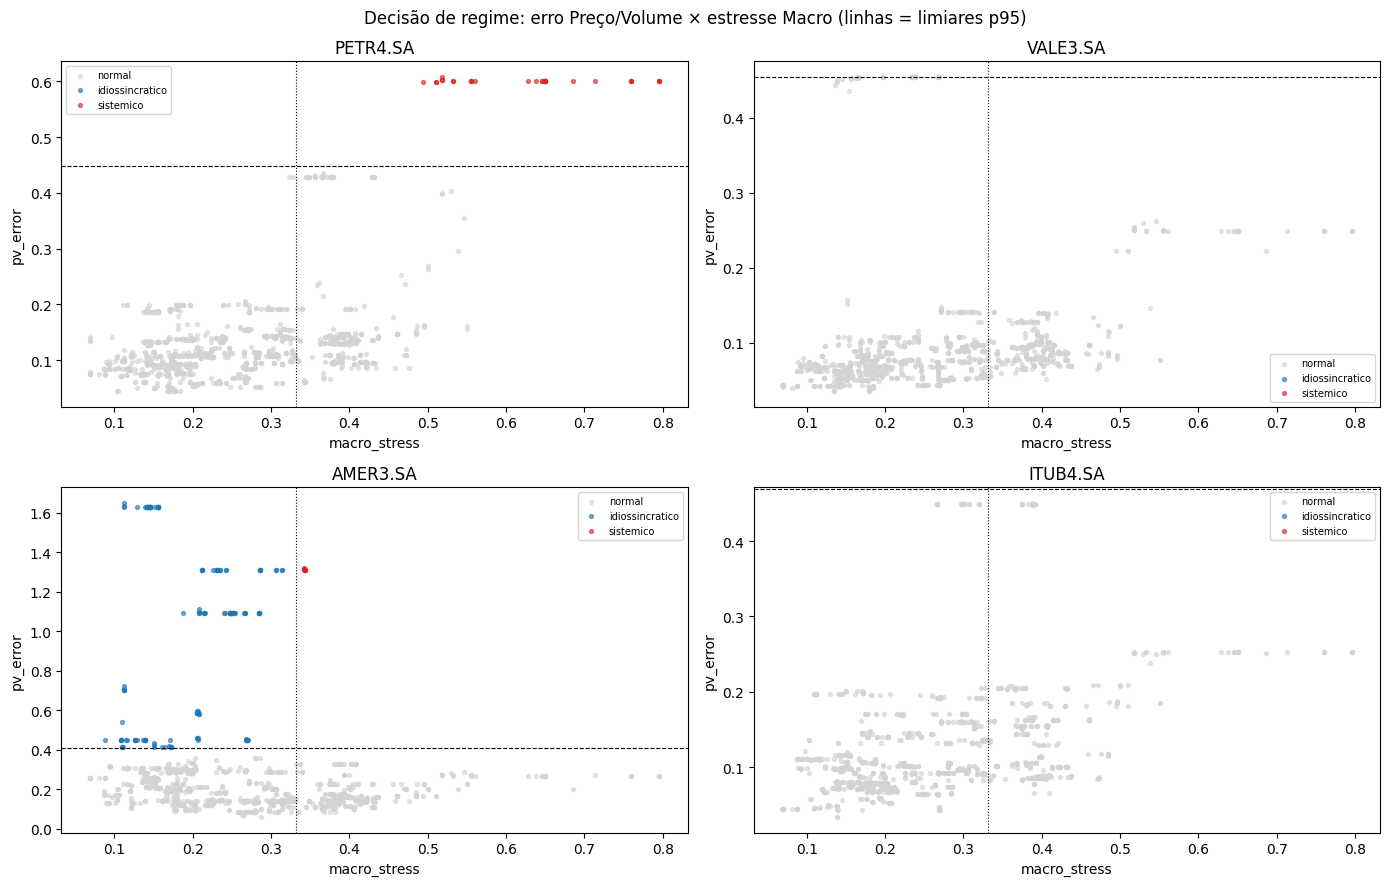

In [4]:
cores = {"normal": "lightgray", "idiossincratico": "tab:blue", "sistemico": "tab:red"}
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, t in zip(axes.ravel(), TICKERS):
    pv, ms, r = out[t]["pv_error"], out[t]["macro_stress"], out[t]["regimes"]
    for reg in ["normal", "idiossincratico", "sistemico"]:
        msk = (r == reg).values
        ax.scatter(ms[msk], pv[msk], s=8, c=cores[reg], label=reg, alpha=0.6)
    ax.axhline(out[t]["pv_thr"], color="k", ls="--", lw=0.8)
    ax.axvline(out[t]["macro_thr"], color="k", ls=":", lw=0.8)
    ax.set_title(t); ax.set_xlabel("macro_stress"); ax.set_ylabel("pv_error")
    ax.legend(fontsize=7)
fig.suptitle("Decisão de regime: erro Preço/Volume × estresse Macro (linhas = limiares p95)")
fig.tight_layout(); save_fig(fig, "m11_conditional_regimes"); plt.show()

## Conclusões

- **A separação funciona.** COVID/2020 sai **sistêmico** (o estresse coincide com macro em
  movimento — VIX, câmbio); a fraude **Americanas/2023** sai **idiossincrático** (AMER3 sob
  estresse, macro estável). É exatamente a distinção que o ADR-0012 buscava.
- **PETR4** (sem evento idiossincrático no teste) tem suas anomalias quase todas **sistêmicas**,
  concentradas na COVID. **AMER3** é dominada por **idiossincrático** (sua própria crise).
- **Macro como contexto, não alvo** (loss só em preço/volume) + **macro_stress por amplitude**
  (não reconstrução) entregam o eixo de decisão sem que eventos macro agendados poluam o erro do
  ativo.
- **Limitações (ADR-0012):** lag de publicação do IPCA é aproximado; `latent_dim` do espaço
  pv+macro ainda não revalidado por walk-forward; indicadores mensais (Selic/IPCA) são quase
  inertes — o sinal sistêmico vem sobretudo de USDBRL/VIX (diários).